In [1]:
import csv
import os 
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import torch

In [2]:
os.chdir(os.getenv("PYTHONPATH"))
!pwd

/Users/miguelmartins/Projects/ESSL-identifiability


In [3]:
log_path = os.path.join(os.getcwd(), "Equivariant_Network/logs/0")

In [4]:
logs = np.array(os.listdir(log_path))

In [5]:
probe_idx = np.char.endswith(logs, '_probe.csv')
pre_idx = ~probe_idx

In [6]:
probes = [os.path.join(log_path, x) for x in logs[probe_idx]]
pretrain = [os.path.join(log_path, x) for x in logs[pre_idx]]

In [7]:
probes, pretrain

(['/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr.yaml_202511141253_probe.csv',
  '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr3_c4.yaml_202511141253_probe.csv',
  '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr_c4.yaml_202511141253_probe.csv',
  '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_sup.yaml_202511141253_probe.csv',
  '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_none_c4.yaml_202511141253_probe.csv',
  '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_sup_c4.yaml_202511141253_probe.csv',
  '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr2_c4.yaml_202511141253_probe.csv',
  '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_crop_c4.yaml_202511141253_pr

In [8]:

def get_df(file_path):
    # --- Step 1: Read the file lines
    # Read raw rows with csv to be robust to commas/quotes
    with open(file_path, newline="") as f:
        rows = list(csv.reader(f))
    
    # Find the table header row ("epoch,train_acc,...")
    header_idx = next(i for i, r in enumerate(rows) if r and r[0].strip() == "epoch")
    
    # --- Parse metadata safely (only rows with exactly two cells)
    metadata = {}
    for r in rows[:header_idx]:
        if len(r) == 2:  # skip lines like ['""'] or ['']
            k, v = r
            metadata[k.strip()] = v.strip()
    
    # --- Parse the training table
    header = rows[header_idx]
    data = rows[header_idx + 1:]
    df = pd.DataFrame(data, columns=header)
    
    # Make numeric columns numeric
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    
    return df

In [9]:
def get_c4(logs):
    return np.array(sorted([x for x in logs if "c4" in x]))

In [23]:
probes_c4 = get_c4(probes)
pretrain_c4 = get_c4(pretrain)

In [24]:
probes_c4

array(['/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_crop_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_none_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr2_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr3_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_sup_c4.yaml_202511141253_probe.csv'],
      dtype='<U123')

In [26]:
probes_c4 = get_c4(probes)
pretrain_c4 = get_c4(pretrain)
probes_c4 = probes_c4[[1, 0, 5, 4, 2, 3]]
pretrain_c4 = pretrain_c4[[1, 0, 5, 4, 2, 3]]
probes_c4

array(['/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_none_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_crop_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_sup_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr2_c4.yaml_202511141253_probe.csv',
       '/Users/miguelmartins/Projects/ESSL-identifiability/Equivariant_Network/logs/0/config_simclr3_c4.yaml_202511141253_probe.csv'],
      dtype='<U123')

In [27]:
names = ["none", "crop", "sup", "simclr", "simclr2", "simclr3"]

In [28]:
get_df(probes_c4[0]), get_df(pretrain[1])

(     epoch  train_loss  train_acc  test_acc  adv_acc  rot_acc
 0        0         NaN    0.50860    0.6094   0.5169      NaN
 1        1         NaN    0.62512    0.6563   0.5873      NaN
 2        2         NaN    0.65162    0.6403   0.5774      NaN
 3        3         NaN    0.66550    0.6665   0.5741      NaN
 4        4         NaN    0.67280    0.6377   0.5692      NaN
 ..     ...         ...        ...       ...      ...      ...
 195    195         NaN    0.72990    0.7130   0.6408      NaN
 196    196         NaN    0.73006    0.7146   0.6386      NaN
 197    197         NaN    0.73144    0.7142   0.6382      NaN
 198    198         NaN    0.73040    0.7154   0.6456      NaN
 199    199         NaN    0.72902    0.7128   0.6360      NaN
 
 [200 rows x 6 columns],
      epoch  train_loss  train_acc  test_acc  adv_acc  rot_acc
 0        0         NaN    0.11794    0.1547   0.1527  0.32546
 1        1         NaN    0.14878    0.1828   0.1835  0.39900
 2        2         NaN    0

In [96]:
rot_accs = []
test_accs = []
adv_accs = []
running_avg_size = 10
df_logs = {}
for i in range(len(names)): # we ignore none because i messed up the logs
    downstream = get_df(probes_c4[i])
    pre = get_df(pretrain_c4[i])
    rot_acc = np.mean(pre["rot_acc"].values[-running_avg_size:])
    test_acc = np.mean(downstream["test_acc"].values[-running_avg_size:])
    adv_acc = np.mean(downstream["adv_acc"].values[-running_avg_size:])
    df_logs[names[i]] = {"rotation": rot_acc, "probe": test_acc, "probe_adv": adv_acc}

df_logs = pd.DataFrame(df_logs).T
    #rot_acc = np.mean(downstream[-running_avg_size:])
    #rot_acc = np.mean(downstream[-running_avg_size:])

In [97]:
print(df_logs)

         rotation    probe  probe_adv
none     1.000000  0.71346    0.63995
crop     1.000000  0.72594    0.64498
sup      1.000000  0.79750    0.72181
simclr   0.931224  0.84391    0.80821
simclr2  0.913206  0.83925    0.82618
simclr3  0.877946  0.81042    0.80553


In [98]:
import itertools
metrics = ["rotation", "probe", "probe_adv"]
def pareto_mask(df, cols):
    vals = df[cols].to_numpy()
    n = vals.shape[0]
    is_pareto = np.ones(n, dtype=bool)

    for i in range(n):
        if not is_pareto[i]:
            continue
        for j in range(n):
            if i == j:
                continue
            # j dominates i (we assume **higher is better** for every metric)
            if np.all(vals[j] >= vals[i]) and np.any(vals[j] > vals[i]):
                is_pareto[i] = False
                break
    return is_pareto

mask_pareto = pareto_mask(df_logs, metrics)
pareto_df = df_logs[mask_pareto]


In [99]:
df_logs

,rotation,probe,probe_adv
none,1.000000,0.71346,0.63995
crop,1.000000,0.72594,0.64498
sup,1.000000,0.79750,0.72181
simclr,0.931224,0.84391,0.80821
simclr2,0.913206,0.83925,0.82618
simclr3,0.877946,0.81042,0.80553


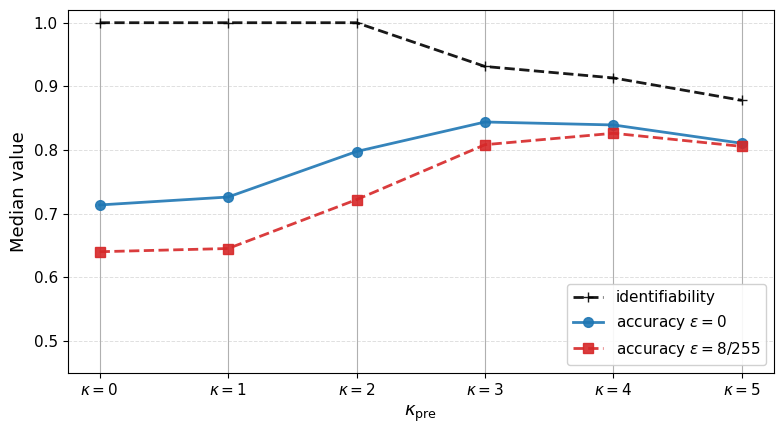

In [101]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(df_logs))  # one x point per κ

fig, ax = plt.subplots(figsize=(8, 4.5))
name_map = {
    "none": r"$\kappa=0$",
    "crop": r"$\kappa=1$",
    "sup": r"$\kappa=2$",
    "simclr": r"$\kappa=3$",
    "simclr2": r"$\kappa=4$",
    "simclr3": r"$\kappa=5$",
}
# Legend labels
y_label = [
    r"identifiability",
    r"accuracy $\epsilon = 0$",
    r"accuracy $\epsilon = 8/255$",
]

# Style per metric (order must match `metrics`)
colors     = ["black", "tab:blue", "tab:red"]
linestyles = ["--", "-", "--"]
markers    = ["+", "o", "s"]

for i, metric in enumerate(metrics):
    y = df_logs[metric].values
    ax.plot(
        x,
        y,
        label=y_label[i],
        color=colors[i],
        linestyle=linestyles[i],
        marker=markers[i],
        linewidth=2.0,
        markersize=7,
        alpha=0.9,
    )

# x-axis ticks are your κ labels
ax.set_xticks(x)
ax.set_xticklabels([name_map[idx] for idx in df_logs.index], fontsize=11)

# Axis labels
ax.set_ylabel("Median value", fontsize=13)
ax.set_xlabel(r"$\kappa_{\text{pre}}$", fontsize=13)

# Optional: match the y-range of the example
ax.set_ylim(0.45, 1.02)

# Horizontal dashed grid only
ax.grid(True, axis="y", linestyle="--", linewidth=0.7, alpha=0.4)

# Ticks
ax.tick_params(axis="y", labelsize=11)

# Legend in a box, bottom right
leg = ax.legend(
    loc="lower right",
    fontsize=11,
    frameon=True,
)
leg.get_frame().set_alpha(0.9)

plt.tight_layout()
plt.show()


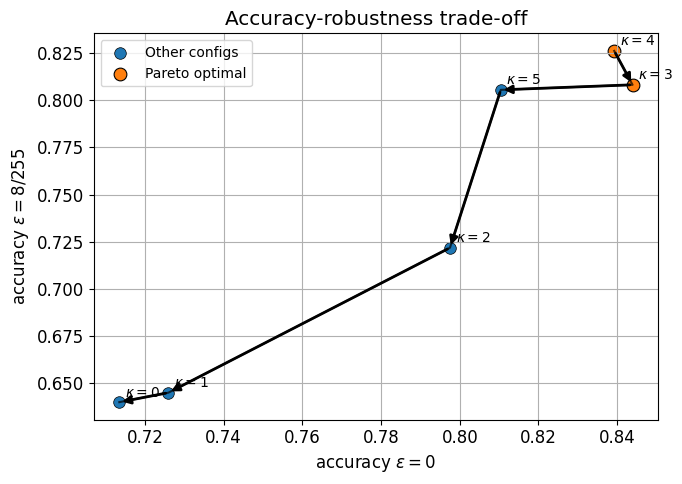

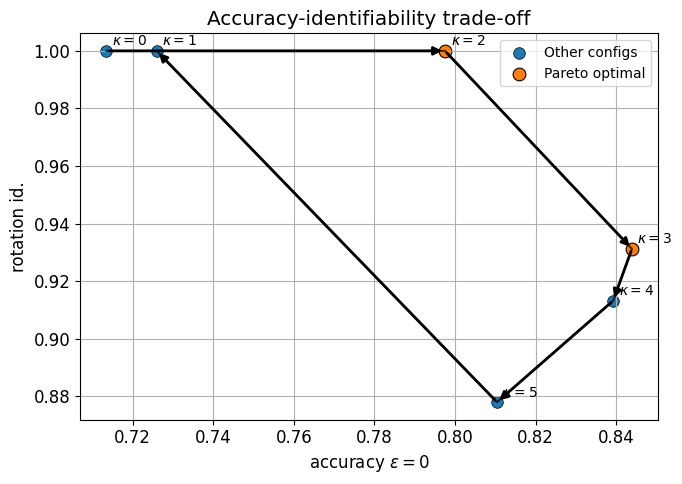

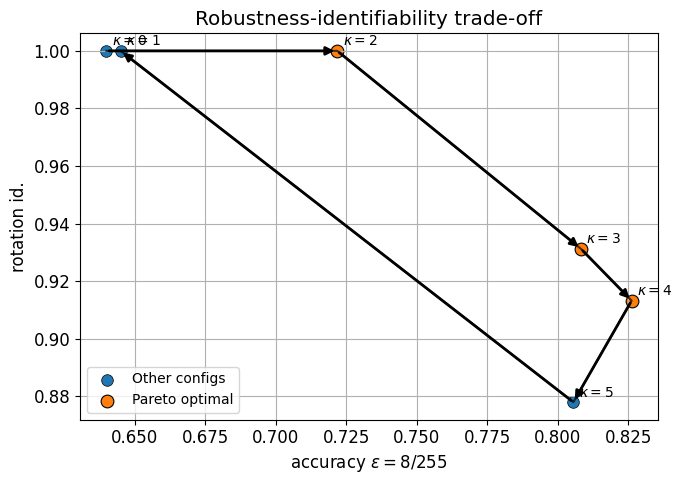

In [92]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- assume df_logs already exists ---
# df_logs.index -> method names ('none', 'crop', 'sup', 'simclr', ...)
# df_logs.columns -> metric names ('probe', 'probe_adv', 'rotation', ...)

metrics = ["probe", "probe_adv", "rotation"]

name_map = {
    "none":   r"$\kappa=0$",
    "crop":   r"$\kappa=1$",
    "sup":    r"$\kappa=2$",
    "simclr": r"$\kappa=3$",
    "simclr2":r"$\kappa=4$",
    "simclr3":r"$\kappa=5$",
}

def get_label(idx):
    return name_map.get(idx, str(idx))

df_logs = df_logs.rename(index=name_map)

# Optional: custom titles per metric pair
# Use the tuple (m1, m2) as key. If not present, a default title is used.
custom_titles = {
    ("probe", "probe_adv"): r"Accuracy-robustness trade-off",
    ("probe", "rotation"): "Accuracy-identifiability trade-off",
    ("probe_adv", "rotation"): "Robustness-identifiability trade-off",
}

label_dict = {
    "probe": r"accuracy $\epsilon=0$",
    "probe_adv": r"accuracy $\epsilon=8/255$",
    "rotation": r"rotation id."
             }


def get_pair_title(m1, m2):
    return custom_titles.get((m1, m2), f"{m1} vs {m2} with Pareto frontier")

# ---------------------------
# 1. Utility: Pareto frontier
# ---------------------------

def pareto_frontier_2d(x, y, maximize_x=True, maximize_y=True):
    """
    Return indices of points that are on the Pareto frontier in 2D.

    All points are assumed to be *maximized*; we optionally flip signs if needed.
    """
    xs = np.array(x)
    ys = np.array(y)

    if not maximize_x:
        xs = -xs
    if not maximize_y:
        ys = -ys

    # sort by x DESC, then sweep in y
    order = np.argsort(-xs)
    xs_sorted = xs[order]
    ys_sorted = ys[order]

    pareto_mask_sorted = np.zeros_like(xs_sorted, dtype=bool)
    best_y = -np.inf
    for i, yv in enumerate(ys_sorted):
        if yv > best_y + 1e-12:
            best_y = yv
            pareto_mask_sorted[i] = True

    pareto_indices = order[pareto_mask_sorted]
    return pareto_indices

import itertools
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# User-configurable plotting settings
# -----------------------------------
TRAJ_COLOR   = "tab:gray"
OTHER_COLOR  = "tab:blue"
PARETO_COLOR = "tab:orange"

FIGSIZE = (7, 5)
MARKER_SIZE = 70
FONT_SIZE = 12

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.grid": True,
})

# -----------------------------------
# User-configurable trade-off weights
# -----------------------------------
# weight_func(alpha) must return a 2-vector of weights for (m1, m2)
# You can change this to any function you like.
def weight_func(alpha: float) -> np.ndarray:
    # linear: alpha for m1, 1-alpha for m2
    return np.array([alpha, 1.0 - alpha])

N_ALPHAS = 201  # how finely to sweep alpha in [0, 1]


def tradeoff_order_indices(df, m1, m2, weight_func, n_alphas=201):
    """
    Determine a trajectory order based on trade-off weights.

    Returns:
        pareto_order : indices that are optimal for some alpha, in alpha order
        full_order   : pareto_order followed by remaining indices sorted by
                      score at alpha=0.5 (or any reference alpha).
    """
    cols = [m1, m2]
    normed = normalize_columns(df, cols)
    vals = normed[cols].values
    n = len(df)

    alphas = np.linspace(0.0, 1.0, n_alphas)
    alpha_hits = {i: [] for i in range(n)}

    for a in alphas:
        w = weight_func(a)
        w = w / w.sum()              # just in case, normalize
        scores = vals @ w
        best = int(scores.argmax())
        alpha_hits[best].append(a)

    # indices that are ever best for some alpha
    best_indices = [i for i in range(n) if len(alpha_hits[i]) > 0]

    # sort those by the smallest alpha where they win
    def alpha_key(i):
        return min(alpha_hits[i]) if alpha_hits[i] else 1e9

    pareto_order = sorted(best_indices, key=alpha_key)

    # remaining (dominated) indices: sort by score at alpha=0.5
    w_mid = weight_func(0.7)
    w_mid = w_mid / w_mid.sum()
    mid_scores = vals @ w_mid
    remaining = [i for i in range(n) if i not in pareto_order]
    remaining_sorted = sorted(remaining, key=lambda i: mid_scores[i], reverse=True)

    full_order = pareto_order + remaining_sorted
    return pareto_order, full_order


# --------------------------------------------------
# 2. Pairwise scatter plots + Pareto & trajectory
# --------------------------------------------------

for m1, m2 in itertools.combinations(metrics, 2):
    fig, ax = plt.subplots(figsize=FIGSIZE)

    x = df_logs[m1].values
    y = df_logs[m2].values

    # --- Pareto vs others (for coloring) ---
    pf_idx = np.array(pareto_frontier_2d(x, y, maximize_x=True, maximize_y=True))
    all_idx = np.arange(len(df_logs))
    other_idx = np.setdiff1d(all_idx, pf_idx)

    pf_points    = df_logs.iloc[pf_idx][[m1, m2]]
    other_points = df_logs.iloc[other_idx][[m1, m2]]

    # --- Trade-off trajectory order ---
    pareto_order, full_order = tradeoff_order_indices(
        df_logs, m1, m2, weight_func, n_alphas=N_ALPHAS
    )

    # Line through ALL points in trade-off order
    traj_x = df_logs[m1].values[full_order]
    traj_y = df_logs[m2].values[full_order]

    ax.plot(
        traj_x,
        traj_y,
        linestyle="-",
        linewidth=1.5,
        color="black",
        alpha=0.7,
    )

    # Add arrows to show direction along trajectory
    for i in range(len(traj_x) - 1):
        ax.annotate(
            "",
            xy=(traj_x[i + 1], traj_y[i + 1]),
            xytext=(traj_x[i], traj_y[i]),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=2.0, alpha=1.0),
        )

    # --- Scatter: non-Pareto points ---
    if len(other_points) > 0:
        ax.scatter(
            other_points[m1],
            other_points[m2],
            s=MARKER_SIZE,
            color=OTHER_COLOR,
            edgecolors="black",
            linewidths=0.5,
            label="Other configs",
        )

    # --- Scatter: Pareto points ---
    ax.scatter(
        pf_points[m1],
        pf_points[m2],
        s=MARKER_SIZE * 1.2,
        color=PARETO_COLOR,
        edgecolors="black",
        linewidths=0.8,
        label="Pareto optimal",
    )

    # --- Labels on each point (κ=0…5) ---
    for xi, yi, label in zip(x, y, df_logs.index):
        ax.annotate(
            label,
            (xi, yi),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=FONT_SIZE - 2,
        )

    ax.set_xlabel(label_dict[m1])
    ax.set_ylabel(label_dict[m2])
    ax.set_title(get_pair_title(m1, m2))
    ax.legend(frameon=True, fontsize=FONT_SIZE - 2)
    plt.tight_layout()
    plt.show()

